# Transcription Factor Project - KOLF2.1J and K562 Perturb-seq Dataset Comparison
**Robin Anwyl, UCSD Subramaniam Lab**

**Goal:** Analyze the KOLF2.1J genome-wide Perturb-seq dataset from the Nourreddine et al. (2024) preprint to investigate the effects of transcription factor knockdowns (TF KDs). Compare to the Replogle et al. (2022) K562 genome-wide Perturb-seq dataset to explore cell-type-specific transcriptional regulatory networks in hiPSCs vs. chronic myeloid leukemia cells.

**Guiding Questions:** What do TF KD effects reveal about:
* the transcriptional regulatory networks of hiPSCs and K562 cells?
* TF crosstalk and co-regulation?
* cell lineage?
* how TFs influence chromatin remodeling?

***

# Import statements

In [1]:
import sys
import os
psp_root = "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/"
if psp_root not in sys.path:
    sys.path.insert(0, psp_root)

import psp

In [2]:
import anndata as ad
import numpy as np
import pandas as pd
import decoupler as dc
import gseapy as gp
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")

# Read in data

In [3]:
filepath = "/home/ranwyl/data_tf_project/KOLF_Pan_Genome_Alpha_CPMnorm_KD_ETest_Gene_gRNA_Filtered.h5ad"
adata_kolf = psp.utils.read_anndata(filepath)
adata_kolf

AnnData object with n_obs × n_vars = 60132 × 16115
    obs: 'gRNA', 'n_gRNA', 'n_gRNA_UMIs', 'gene_target', 'celltype', 'perturbation_type', 'n_UMI_counts', 'n_genes', 'perturbed', 'channel', 'perturbation', 'gene_target_ensembl_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_ids', 'feature_types', 'n_UMI_counts', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'etest_results', 'etest_results_params'
    layers: 'counts'

In [4]:
filepath1 = "/home/ranwyl/results_tf_project/KOLF_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_kolf_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/KOLF_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_kolf_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/KOLF_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_kolf_3 = pd.read_pickle(filepath3)
de_results_kolf = [de_results_kolf_1, de_results_kolf_2, de_results_kolf_3]

In [5]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_NTC_norm_KDefficiency_Etest_gRNA_filtered.h5ad"
adata_k562 = psp.utils.read_anndata(filepath)
adata_k562

AnnData object with n_obs × n_vars = 244096 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'target_detected', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cel

In [6]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_k562_3 = pd.read_pickle(filepath3)
de_results_k562 = [de_results_k562_1, de_results_k562_2, de_results_k562_3]

In [7]:
def validate_3_DGE_results_dfs(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Check that 3 DGE analysis results DFs have same rows and cols.
    """
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    DGE_results_1 = DGE_results_dfs[0].sort_index()
    DGE_results_2 = DGE_results_dfs[1].sort_index()
    DGE_results_3 = DGE_results_dfs[2].sort_index()
    if not (DGE_results_1.index.equals(DGE_results_2.index) and 
            DGE_results_2.index.equals(DGE_results_3.index)):
        raise ValueError("DGE results DataFrames must have same index (genes)")
    if not ((set(DGE_results_1.columns) == set(DGE_results_2.columns)) &
            (set(DGE_results_2.columns) == set(DGE_results_3.columns))):
        raise ValueError("DGE results DataFrames must have same columns (KDs)")
    # Return DFs with sorted index
    return [DGE_results_1, DGE_results_2, DGE_results_3]

def build_3_run_DEGs_dict(DGE_results_dfs: list[pd.DataFrame],
                          p_threshold: float,
                          p_threshold_type: str="pvalue",
                          target_type: str="gRNA",
                          lfc_threshold: float = 0,
                          lfc_col: str = "log2FoldChange",
                          validate: bool=True
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that are DEGs of that KD (pass significance 
    and LFC thresholds) in at least 2 DGE analysis runs.
    """
    # Check for valid significance threshold
    if p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("p_threshold_type must be 'pvalue' or 'padj'")
    # Check for valid target type
    if target_type not in ("gRNA", "gene_target"):
        raise ValueError("target_type must be 'gRNA' or 'gene_target'")
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Find genes that are DEGs of the same KD in at least 2 DGE runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if target_type == "gRNA":
        targets = {"_".join(col.split("_")[:2]) for col in DGE_results_1.columns}
    else:
        targets = {col.split("_")[0] for col in DGE_results_1.columns}
    targets = sorted(list(targets))
    DEGs_dict = dict()
    for target in targets:
        target_p_col = f"{target}_{p_threshold_type}"
        target_lfc_col = f"{target}_{lfc_col}"
        DEGs_run1 = set(
            DGE_results_1.loc[(DGE_results_1[target_p_col] < p_threshold) & 
            (abs(DGE_results_1[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run2 = set(
            DGE_results_2.loc[(DGE_results_2[target_p_col] < p_threshold) & 
            (abs(DGE_results_2[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run3 = set(
            DGE_results_3.loc[(DGE_results_3[target_p_col] < p_threshold) & 
            (abs(DGE_results_3[target_lfc_col]) > lfc_threshold)].index)                                 
        DEGs_at_least_2 = ((DEGs_run1 & DEGs_run2) | (DEGs_run2 & DEGs_run3) |
                           (DEGs_run1 & DEGs_run3))
        DEGs_dict[target] = DEGs_at_least_2
    return DEGs_dict

def build_3_run_n_DEGs_df(DEGs_dict: dict[str, set[str]]
                          ) -> pd.DataFrame:
    """
    From a dict of DEGs for each KD, build a DataFrame reporting
    the number of DEGs per KD.
    """
    kds = list(DEGs_dict.keys())
    n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
    n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    n_DEGs_df = n_DEGs_df.sort_values(by="n_DEGs", ascending=False)
    return n_DEGs_df

In [8]:
kd_deg_dict_kolf = build_3_run_DEGs_dict(de_results_kolf, 
                                         p_threshold=0.02,
                                         p_threshold_type="pvalue",
                                         target_type="gene_target")
kd_n_degs_df_kolf = build_3_run_n_DEGs_df(kd_deg_dict_kolf)
kd_n_degs_df_kolf.head(10)

,n_DEGs
POU5F1,418
DNMT1,122
ZNF521,81
THAP12,43
NANOG,41
ZNF396,41
ADNP2,31
PHF20,29
CHAMP1,24
POU5F1B,23


In [9]:
kd_deg_dict_k562 = build_3_run_DEGs_dict(de_results_k562, 
                                         p_threshold=0.005,
                                         p_threshold_type="pvalue",
                                         target_type="gene_target")
kd_n_degs_df_k562 = build_3_run_n_DEGs_df(kd_deg_dict_k562)
kd_n_degs_df_k562.head(10)

,n_DEGs
DNMT1,406
CXXC1,165
MAX,150
MYB,141
TFDP1,128
TBX1,120
ETV4,106
NKX6-1,103
SETDB1,94
ZBTB17,77


# Compare "strong" TF KDs

In [10]:
tf_kds_by_n_degs_kolf = kd_n_degs_df_kolf.sort_values(by="n_DEGs", ascending=False).index.tolist()
print(tf_kds_by_n_degs_kolf[:5])

['POU5F1', 'DNMT1', 'ZNF521', 'THAP12', 'ZNF396']


In [11]:
tf_kds_by_n_degs_k562 = kd_n_degs_df_k562.sort_values(by="n_DEGs", ascending=False).index.tolist()
print(tf_kds_by_n_degs_k562[:5])

['DNMT1', 'CXXC1', 'MAX', 'MYB', 'TFDP1']


In [12]:
def build_combined_n_DEGs_df(kolf_df, k562_df):
    kolf_df = kolf_df.rename(columns={"n_DEGs": "KOLF_n_DEGs"})
    k562_df = k562_df.rename(columns={"n_DEGs": "K562_n_DEGs"})
    combined_df = kolf_df.join(k562_df, how="outer")
    combined_df = combined_df.astype("Int64")
    combined_df["sum"] = combined_df.sum(axis=1)
    combined_df = combined_df.sort_values(by=["sum"], ascending=False)
    combined_df.drop("sum", axis=1, inplace=True)
    return combined_df

In [41]:
combined_n_degs_df = build_combined_n_DEGs_df(kd_n_degs_df_kolf, kd_n_degs_df_k562)
combined_n_degs_df.head(20)

,KOLF_n_DEGs,K562_n_DEGs
DNMT1,122,406
POU5F1,418,4
CXXC1,<NA>,165
MAX,<NA>,150
MYB,<NA>,141
TFDP1,1,128
TBX1,0,120
SETDB1,22,94
ETV4,<NA>,106
NKX6-1,0,103


In [17]:
def build_combined_DEGs_dict(kolf_DE_results: pd.DataFrame, 
                             k562_DE_results: pd.DataFrame,
                             kolf_p_threshold: float=0.02,
                             k562_p_threshold: float=0.005,
                             kolf_p_threshold_type: str="pvalue",
                             k562_p_threshold_type: str="pvalue"
                             ) -> dict:
    if kolf_p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("kolf_p_threshold_type must be 'pvalue' or 'padj'")
    if k562_p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("k562_p_threshold_type must be 'pvalue' or 'padj'")
    kolf_kds = {col.split("_")[0] for col in kolf_DE_results.columns}
    k562_kds = {col.split("_")[0] for col in k562_DE_results.columns}
    all_kds = kolf_kds | k562_kds
    all_kds = sorted(list(all_kds))
    combined_DEGs_dict = dict()
    for kd in all_kds:
        kolf_DEGs, k562_DEGs = list(), list()
        if kd in kolf_kds:
            kolf_kd_p_col = f"{kd}_{kolf_p_threshold_type}"
            kolf_DEGs = kolf_DE_results.loc[
                kolf_DE_results[kolf_kd_p_col] < kolf_p_threshold].index.tolist()
            kolf_DEGs.sort()
            if kd in kolf_DEGs:
                kolf_DEGs.remove(kd)
        if kd in k562_kds:
            k562_kd_p_col = f"{kd}_{k562_p_threshold_type}"
            k562_DEGs = k562_DE_results.loc[
                k562_DE_results[k562_kd_p_col] < k562_p_threshold].index.tolist()
            k562_DEGs.sort()
            if kd in k562_DEGs:
                k562_DEGs.remove(kd)
        combined_DEGs_dict[kd] = {"KOLF": kolf_DEGs, "K562": k562_DEGs}
    return combined_DEGs_dict

def build_combined_DEGs_df(combined_DEGs_dict: dict,
                           kd_list: list[str] | None = None):
    if kd_list is None:
        kd_list = sorted(list(combined_DEGs_dict.keys))
    n_kolf_DEGs, n_k562_DEGs, n_shared_DEGs = list(), list(), list()
    kolf_DEGs_entries, k562_DEGs_entries, shared_DEGs_entries = list(), list(), list()
    for kd in kd_list:
        if kd not in combined_DEGs_dict:
            continue
        if combined_DEGs_dict[kd]["KOLF"]:
            kolf_DEGs_entries.append(', '.join(combined_DEGs_dict[kd]["KOLF"]))
            n_kolf_DEGs.append(len(combined_DEGs_dict[kd]["KOLF"]))
        else:
            kolf_DEGs_entries.append("")
            n_kolf_DEGs.append(0)
        if combined_DEGs_dict[kd]["K562"]:
            k562_DEGs_entries.append(', '.join(combined_DEGs_dict[kd]["K562"]))
            n_k562_DEGs.append(len(combined_DEGs_dict[kd]["K562"]))
        else:
            k562_DEGs_entries.append("")
            n_k562_DEGs.append(0)
        shared_DEGs = sorted(list(
            set(combined_DEGs_dict[kd]["KOLF"]) & 
            set(combined_DEGs_dict[kd]["K562"])
            ))
        if shared_DEGs:
            shared_DEGs_entries.append(', '.join(shared_DEGs))
            n_shared_DEGs.append(len(shared_DEGs))
        else:
            shared_DEGs_entries.append("")
            n_shared_DEGs.append(0)
    combined_DEGs_df = pd.DataFrame({"n_KOLF_DEGs": n_kolf_DEGs, 
                                     "n_K562_DEGs": n_k562_DEGs,
                                     "n_shared_DEGs": n_shared_DEGs,
                                     "KOLF_DEGs": kolf_DEGs_entries,
                                     "K562_DEGs": k562_DEGs_entries,
                                     "shared_DEGs": shared_DEGs_entries},
                                     index=kd_list)
    return combined_DEGs_df

In [18]:
combined_degs_dict = build_combined_DEGs_dict(de_results_kolf, de_results_k562, 
                                              kolf_p_threshold=0.02, k562_p_threshold=0.005)

In [14]:
def report_3_run_KD_DGE_results_consistent_DEGs(
        DGE_results_dfs: list[pd.DataFrame],
        ntc_threshold: int,
        strong_kd_threshold: int = 10,
        adata: ad.AnnData | None = None,
        p_threshold: float = 0.05,
        p_threshold_type: str = "pvalue",
        gene_target_col: str = "gene",
        report_target_detected: bool = True,
        target_detected_col: str = "target_detected"):
    # Build dict of each gRNA and its DEGs in 2+ DGE runs
    kd_DEG_dict = build_3_run_DEGs_dict(DGE_results_dfs, 
                                        p_threshold=p_threshold,
                                        p_threshold_type=p_threshold_type,
                                        target_type="gene_target")
    kds_pass_ntc_threshold = {kd for kd in kd_DEG_dict.keys() 
                              if len(kd_DEG_dict[kd]) > ntc_threshold}
    kds_strong = {kd for kd in kd_DEG_dict.keys() 
                  if len(kd_DEG_dict[kd]) >= strong_kd_threshold}
    
    # Report results
    print(f"{len(kds_pass_ntc_threshold)} out of {len(kd_DEG_dict)} KDs have " 
          f">{ntc_threshold} consistent DEGs (pass NTC DEG threshold) in at least 2 of 3 DGE runs")
    print(f"{len(kds_strong)} out of {len(kd_DEG_dict)} KDs are consistent strong KDs "
          f"(have ≥{strong_kd_threshold} consistent DEGs) in at least 2 of 3 DGE runs")

    if report_target_detected:
        kds_target_detected = set(adata[adata.obs[target_detected_col] == "True"].obs[gene_target_col])
        kds_target_undetected = set(adata[adata.obs[target_detected_col] == "False"].obs[gene_target_col])
        kds_pass_target_detected = kds_pass_ntc_threshold & kds_target_detected
        kds_pass_target_undetected = kds_pass_ntc_threshold & kds_target_undetected
        print()
        print(f"Out of {len(kds_pass_ntc_threshold)} KDs that pass NTC DEG threshold in at least 2 runs:")
        print(f"{len(kds_pass_target_detected)} KDs have a detectable gene target")
        print(f"{len(kds_pass_target_undetected)} KDs have an undetectable gene target")
        
        strong_kds_target_detected = kds_strong & kds_target_detected
        strong_kds_target_undetected = kds_strong & kds_target_undetected
        print()
        print(f"Out of {len(kds_strong)} KDs that are strong in at least 2 runs:")
        print(f"{len(strong_kds_target_detected)} KDs have a detectable gene target")
        print(f"{len(strong_kds_target_undetected)} KDs have an undetectable gene target")

    return kds_pass_ntc_threshold, kds_strong

## Union vs. intersection of TF KDs

In [15]:
strong_tf_kd_deg_threshold = 10

In [18]:
print("KOLF2.1J hiPSC dataset")
tf_kds_pass_ntc_kolf, strong_tf_kds_kolf = \
    report_3_run_KD_DGE_results_consistent_DEGs(de_results_kolf,
                                                ntc_threshold=3,
                                                strong_kd_threshold=10,
                                                p_threshold=0.02,
                                                p_threshold_type="pvalue",
                                                report_target_detected=False)

KOLF2.1J hiPSC dataset
45 out of 349 KDs have >3 consistent DEGs (pass NTC DEG threshold) in at least 2 of 3 DGE runs
17 out of 349 KDs are consistent strong KDs (have ≥10 consistent DEGs) in at least 2 of 3 DGE runs


In [19]:
print("K562 dataset")
tf_kds_pass_ntc_k562, strong_tf_kds_k562 = \
    report_3_run_KD_DGE_results_consistent_DEGs(de_results_k562,
                                                ntc_threshold=4,
                                                strong_kd_threshold=10,
                                                p_threshold=0.005,
                                                p_threshold_type="pvalue",
                                                report_target_detected=False)

K562 dataset


457 out of 916 KDs have >4 consistent DEGs (pass NTC DEG threshold) in at least 2 of 3 DGE runs
197 out of 916 KDs are consistent strong KDs (have ≥10 consistent DEGs) in at least 2 of 3 DGE runs


Shared strong TF KDs

In [21]:
shared_strong_tf_kds = strong_tf_kds_kolf & strong_tf_kds_k562
print(f"{len(shared_strong_tf_kds)} shared strong TF KDs")
print(', '.join(shared_strong_tf_kds))

8 shared strong TF KDs
THAP12, ZNF787, SETDB1, FOXD3, DNMT1, REST, ADNP2, ZNF462


In [42]:
combined_n_degs_df[combined_n_degs_df.index.isin(shared_strong_tf_kds)]

,KOLF_n_DEGs,K562_n_DEGs
DNMT1,122,406
SETDB1,22,94
THAP12,43,12
ADNP2,31,17
ZNF462,11,32
REST,10,30
ZNF787,14,18
FOXD3,15,13


Strong TF KDs that are in the union of TF KDs across both datasets

In [22]:
tf_kds_union = set(kd_n_degs_df_kolf.index) | set(kd_n_degs_df_k562.index)
print(len(tf_kds_union))

1063


In [23]:
print(f"hiPSC: {len(strong_tf_kds_kolf)} strong TF KDs with {strong_tf_kd_deg_threshold}+ DEGs")

hiPSC: 17 strong TF KDs with 10+ DEGs


In [24]:
print(f"K562: {len(strong_tf_kds_k562)} strong TF KDs with {strong_tf_kd_deg_threshold}+ DEGs")

K562: 197 strong TF KDs with 10+ DEGs


In [25]:
from matplotlib_venn import venn2

Text(0.5, 1.0, 'Strong TF KDs (10+ DEGs)\nin union of TF KDs from both datasets')

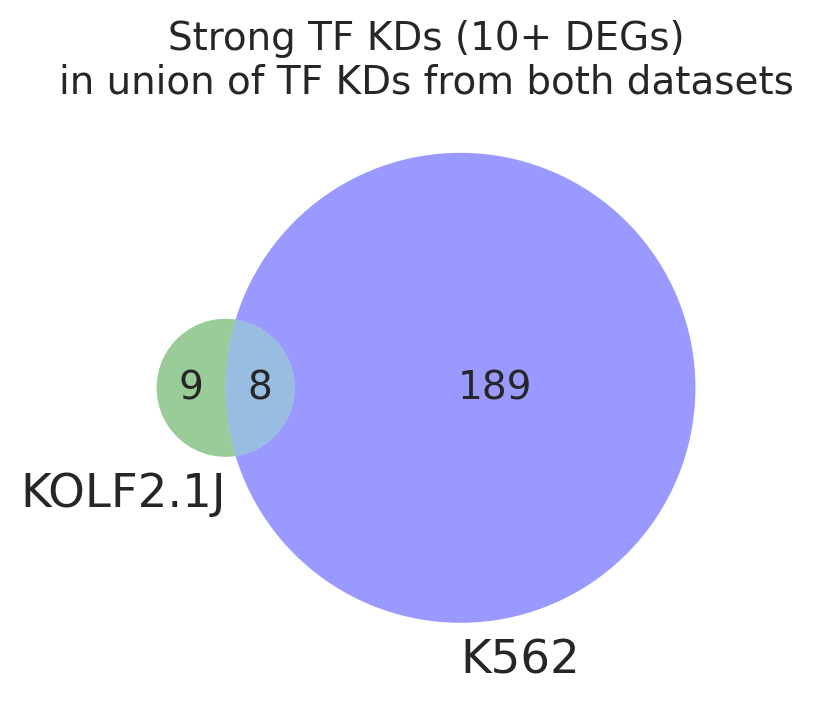

In [26]:
_, ax = plt.subplots(1, 1)
venn2([strong_tf_kds_kolf, strong_tf_kds_k562], set_labels=["KOLF2.1J", "K562"],
       set_colors=["green", "blue"], ax=ax)
ax.set_title("Strong TF KDs (10+ DEGs)\nin union of TF KDs from both datasets")

In [27]:
unique_strong_tf_kds_kolf = strong_tf_kds_kolf - strong_tf_kds_k562
print(len(unique_strong_tf_kds_kolf))
unique_strong_tf_kds_k562 = strong_tf_kds_k562 - strong_tf_kds_kolf
print(len(unique_strong_tf_kds_k562))

9
189


In [28]:
unique_strong_tf_kds_kolf_ordered = [kd for kd in tf_kds_by_n_degs_kolf 
                                     if kd in unique_strong_tf_kds_kolf]
unique_strong_tf_kds_k562_ordered = [kd for kd in tf_kds_by_n_degs_k562 
                                     if kd in unique_strong_tf_kds_k562]

In [29]:
print(f"Shared strong TF KDs: {', '.join(set(strong_tf_kds_kolf) & set(strong_tf_kds_k562))}")

Shared strong TF KDs: THAP12, ZNF787, SETDB1, DNMT1, FOXD3, REST, ADNP2, ZNF462


In [30]:
print(f"Top 20 strong TF KDs unique to KOLF: {', '.join(unique_strong_tf_kds_kolf_ordered[:20])}")
print(f"Top 20 strong TF KDs unique to K562: {', '.join(unique_strong_tf_kds_k562_ordered[:20])}")

Top 20 strong TF KDs unique to KOLF: POU5F1, ZNF521, ZNF396, NANOG, PHF20, CHAMP1, POU5F1B, FOXH1, POU3F2
Top 20 strong TF KDs unique to K562: CXXC1, MAX, MYB, TFDP1, TBX1, ETV4, NKX6-1, ZBTB17, POU3F1, TBP, THAP2, DRAP1, NRF1, ZNF84, MBD3, ZNF574, HINFP, SP1, ZNF207, HMX3


Strong TF KDs that are in the intersection of TF KDs across both datasets

In [31]:
tf_kds_intersection = set(kd_n_degs_df_kolf.index) & set(kd_n_degs_df_k562.index)
print(len(tf_kds_intersection))

202


In [32]:
strong_intersec_tf_kds_kolf = strong_tf_kds_kolf & tf_kds_intersection
print(f"hiPSC: {len(strong_intersec_tf_kds_kolf)} strong TF KDs with {strong_tf_kd_deg_threshold}+ DEGs "
      "in intersection of TF KDs")

hiPSC: 15 strong TF KDs with 10+ DEGs in intersection of TF KDs


In [33]:
strong_intersec_tf_kds_k562 = strong_tf_kds_k562 & tf_kds_intersection
print(f"K562: {len(strong_intersec_tf_kds_k562)} strong TF KDs with {strong_tf_kd_deg_threshold}+ DEGs "
      "in intersection of TF KDs")

K562: 51 strong TF KDs with 10+ DEGs in intersection of TF KDs


Text(0.5, 1.0, 'Strong TF KDs (10+ DEGs)\nin intersection of TF KDs from both datasets')

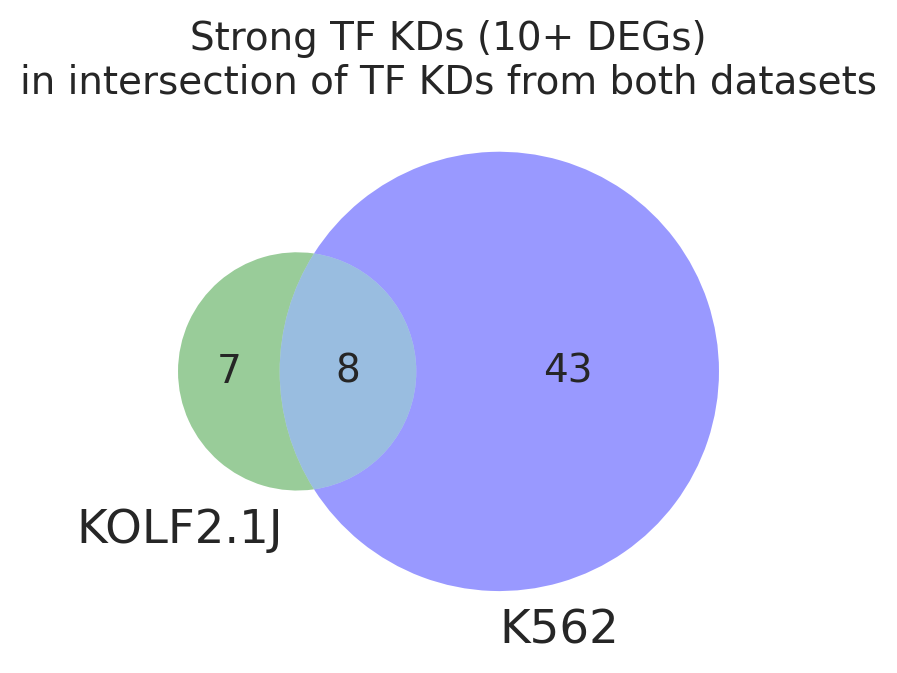

In [34]:
_, ax = plt.subplots(1, 1)
venn2([strong_intersec_tf_kds_kolf, strong_intersec_tf_kds_k562], set_labels=["KOLF2.1J ", "K562"],
       set_colors=["green", "blue"], ax=ax)
ax.set_title("Strong TF KDs (10+ DEGs)\nin intersection of TF KDs from both datasets")

In [35]:
unique_strong_intersec_tf_kds_kolf = strong_intersec_tf_kds_kolf - strong_intersec_tf_kds_k562
print(len(unique_strong_intersec_tf_kds_kolf))
unique_strong_intersec_tf_kds_k562 = strong_intersec_tf_kds_k562 - strong_intersec_tf_kds_kolf
print(len(unique_strong_intersec_tf_kds_k562))

7
43


In [36]:
unique_strong_intersec_tf_kds_kolf_ordered = [kd for kd in tf_kds_by_n_degs_kolf 
                                     if kd in unique_strong_intersec_tf_kds_kolf]
unique_strong_intersec_tf_kds_k562_ordered = [kd for kd in tf_kds_by_n_degs_k562 
                                     if kd in unique_strong_intersec_tf_kds_k562]

In [37]:
print(f"Strong TF KDs unique to KOLF: {', '.join(unique_strong_intersec_tf_kds_kolf_ordered)}")

Strong TF KDs unique to KOLF: POU5F1, ZNF396, NANOG, PHF20, CHAMP1, POU5F1B, FOXH1


In [39]:
kd_n_degs_df_kolf[kd_n_degs_df_kolf.index.isin(unique_strong_intersec_tf_kds_kolf_ordered)]

,n_DEGs
POU5F1,418
NANOG,41
ZNF396,41
PHF20,29
CHAMP1,24
POU5F1B,23
FOXH1,20


In [38]:
print(f"Strong TF KDs unique to K562: {', '.join(unique_strong_intersec_tf_kds_k562_ordered)}")

Strong TF KDs unique to K562: TFDP1, TBX1, NKX6-1, MBD3, SP1, HMX3, ZBTB4, ZNF292, ZNF687, MEIS3, CAMTA2, ZBTB44, BHLHE40, HMBOX1, ZNF695, PHF1, ZBTB39, POGK, ETS1, MAFK, SOX11, GPBP1, SPI1, ARID2, ZNF557, DLX2, LYL1, GPBP1L1, LCOR, PAX2, IRX1, ZNF420, RFX6, MYPOP, WT1, ZNF320, ZNF763, FOXG1, ZNF34, ELF4, ZNF853, LIN28A, SIX6


In [45]:
kd_n_degs_df_k562[kd_n_degs_df_k562.index.isin(unique_strong_intersec_tf_kds_k562_ordered)].head(10)

,n_DEGs
TFDP1,128
TBX1,120
NKX6-1,103
MBD3,58
SP1,54
HMX3,52
ZBTB4,47
ZNF292,43
ZNF687,40
MEIS3,37


## DEGs

In [19]:
shared_strong_tf_kds_degs_df = build_combined_DEGs_df(combined_degs_dict, 
                                                      kd_list=shared_strong_tf_kds)

In [20]:
shared_strong_tf_kds_degs_df

,n_KOLF_DEGs,n_K562_DEGs,n_shared_DEGs,KOLF_DEGs,K562_DEGs,shared_DEGs
ADNP2,52,30,1,"ACTC1, ADD3-AS1, AKR1C3, ALG1L9P, BST2, CPEB1,...","AC016074.2, AC023157.3, ARG2, BST2, CHI3L2, DD...",BST2
BHLHE40,13,31,0,"ALG6, AQP11, BAG2, CFAP92, COQ7, ENSG000002801...","AIF1, ANXA3, ATF5, CHEK1, CLIC1, CTNNAL1, DARS...",
CHAMP1,45,17,0,"AFG1L, BBS9, BMPR1B, BST2, DHRS3, ENSG00000226...","ALAS2, ATF5, DDIT3, DDIT4, GABPB1-AS1, GDF15, ...",
HMX3,11,51,0,"CCN2, ENSG00000288595, IADEN, KIF1C, LINC01405...","AL034397.3, ALAS2, ASF1B, BTG1, BTG2, CLCA1, C...",
PHF1,25,35,0,"C4orf36, CCDC102A, CDK5, CREB5, DAPK2, ENSG000...","ACP5, AIF1, ALAS2, ASF1A, CA8, CHI3L2, CLCA1, ...",
PHF20,33,14,0,"ADCY2, ARL4C, CADM1, CRABP2, DACH1, DPP10, ENS...","ATP6V0E2, CAVIN1, ECD, EMILIN2, ETHE1, FAM229B...",
REST,14,49,0,"CADPS, CHGA, COQ8A, CPLX2, GPR158, NMNAT2, PCS...","AIF1, AREG, ATF3, ATF5, BBC3, BEX2, BTG2, CHD2...",
SETDB1,25,122,0,"COPS7A, CTCFL, DHRS2, DMP1-AS1, ENSG0000022373...","ABCB6, AC016074.2, AC023157.3, AC079466.1, AC0...",
THAP12,61,13,3,"AGFG1, ANKRD36C, ANKRD46, BBS9, BOLA3, BOLA3-D...","AAAS, ACVR1B, BLVRB, BOLA3, CHORDC1, HBZ, NLE1...","BOLA3, REX1BD, ZNF22"
ZNF426,17,10,0,"BMPR1B, CCDC65, EDNRA, ENSG00000267055, ENSG00...","BTG2, CDKN1C, CRYM, DYM, HBD, HBZ, MR1, MTMR6,...",


In [ ]:
print(combined_degs_dict["PCGF6"])

{'KOLF': ['ANKRD36', 'ANXA3', 'CLN3', 'ENSG00000237844', 'ENSG00000251652', 'ENSG00000282885', 'FBXW10B', 'HMOX1', 'IRAK3', 'JAM2', 'KCNQ1OT1', 'LEPROT', 'MIDEAS', 'NETO2', 'RNF157', 'RNF212', 'SETD1B', 'SLC17A9', 'SLC26A6', 'STXBP6'], 'K562': ['AC016629.2', 'CPD', 'IGFBP2', 'PRTFDC1', 'TBX2-AS1', 'TMEM54']}


In [33]:
print(combined_degs_dict["ZNF280B"])

{'KOLF': ['AMPD2', 'DGCR5', 'FBN3', 'HELLPAR', 'HTR1F', 'LINC01234', 'LINC01418', 'PDE10A', 'RTL8B', 'TANC2', 'ZBED3-AS1'], 'K562': ['BTG2', 'EGR1', 'H19', 'IER3', 'JUN', 'MED21', 'PHF21A', 'WDR45B']}


In [41]:
shared_strong_tf_kds_degs_df_low_tfs = build_combined_DEGs_df(combined_degs_dict_low_tfs, 
                                                      kd_list=shared_strong_tf_kds_low_tfs)

In [42]:
shared_strong_tf_kds_degs_df_low_tfs

,n_KOLF_DEGs,n_K562_DEGs,n_shared_DEGs,KOLF_DEGs,K562_DEGs,shared_DEGs
ADNP2,52,23,1,"ACTC1, ADD3-AS1, AKR1C3, ALG1L9P, BST2, CPEB1,...","AP002387.2, ATF7IP2, BST2, CHI3L2, DENND2D, EC...",BST2
BATF,13,11,0,"ADAM9, ARRDC1, ATPSCKMT, B3GAT1-DT, ENSG000002...","ALAS2, BBC3, CCDC115, EGR1, GATD3B, GDF15, LSM...",
BHLHE40,13,37,0,"ALG6, AQP11, BAG2, CFAP92, COQ7, ENSG000002801...","AIF1, ALDH1B1, ANKZF1, ATF5, CLCA1, CPPED1, CT...",
CHAMP1,45,16,0,"AFG1L, BBS9, BMPR1B, BST2, DHRS3, ENSG00000226...","DDIT3, GTF2H1, JUN, KATNAL1, LINC02573, MFSD5,...",
DMBX1,17,14,0,"ABHD4, ACTN2, ANKMY1, EIF5AL1, ENSG00000286050...","ALAS2, BTG2, ERMAP, GAS5, GIHCG, HBD, HBG2, HE...",
ESRRG,22,11,0,"ATP13A1, AVIL, CCDC85A, CHODL, DDX51, DTX2, EN...","ALAS2, BAG1, BTG2, COTL1, DDIT4, IER3, JUN, KL...",
ETS1,12,14,0,"ALPK3, GSDME, HRH2, ILVBL, KLHL22, LAMC3, LPL,...","CPPED1, CRYM, DDIT3, DDIT4, HBZ, IGFBP2, JUN, ...",
FOXD3,17,13,0,"ACADSB, CCDC26, DLGAP1, ENSG00000228204, ERG, ...","ALAS2, CLCA1, DDIT3, EGR1, FANCA, H19, IER3, J...",
FOXH1,33,15,0,"ADAM19, ADHFE1, ARHGEF35-AS1, AUTS2, CACNA2D3,...","ABI1, ATF3, CD7, DDIT3, GABARAPL1, GDF15, GNB1...",
HMX3,11,55,0,"CCN2, ENSG00000288595, IADEN, KIF1C, LINC01405...","AC005670.3, ACP5, ACTR6, AL034397.3, BTG1, BTG...",


## GSEA

In [14]:
def prerank_gsea_kd_list(
        kds: list[str], 
        DE_results: pd.DataFrame, 
        gene_set_lib: str, 
        rank_by: str="stat",
        min_term_size: int=5, 
        max_term_size: int=1000, 
        permutation_num: int=1000, 
        n_cpus_per_job: int=4,
        n_jobs: int=1,
        random_seed: int=42,
        verbose: bool=False,
        kd_col: str="KD",
        column_0_label: str | None = None,
        column_0_value: str | None = None
    ) -> pd.DataFrame:
    """
    Run pre-ranked GSEA using the given Enrichr library on each 
    individual KD in a list. By default, rank genes by 
    Wald test statistic. min_size and max_size control Enrichr term size.
    """
    # Helper function to run GSEA on single KD
    def process_kd(kd):
        # Rank genes for KD
        rank_df = pd.DataFrame(DE_results[f"{kd}_{rank_by}"].values,
                               columns=[rank_by],
                               index=DE_results.index)
        rank_df.dropna(axis="index", inplace=True) # Drop NaN values
        rank_df.index.name = "gene"
        rank_df.sort_values(by=rank_by, ascending=False, inplace=True)
        # Run pre-ranked GSEA
        kd_prerank_result = \
            gp.prerank(rnk=rank_df,
                        gene_sets=gene_set_lib,
                        threads=n_cpus_per_job,
                        min_size=min_term_size,
                        max_size=max_term_size,
                        permutation_num=permutation_num,
                        outdir=None,
                        seed=random_seed,
                        verbose=verbose,
                        )
        return kd_prerank_result
    
    # Run GSEA on all KDs
    if n_jobs < 1:
        raise ValueError("Invalid value for n_jobs")
    if n_jobs == 1:
        kd_prerank_results_dict = dict()
        for kd in kds:
            kd_prerank_result = process_kd(kd)
            kd_prerank_results_dict[kd] = kd_prerank_result
    else: # Run in parallel
        with tqdm_joblib(desc="Running pre-ranked GSEA", 
                         total=len(kds)):
            kd_prerank_results = Parallel(n_jobs=n_jobs)(
                delayed(process_kd)(kd) for kd in kds)
        kd_prerank_results_dict = dict(zip(kds, kd_prerank_results))
    
    # Build results DF
    prerank_res_df_list = list()
    for kd in kd_prerank_results_dict:
        # Build results DF for KD
        kd_res_df = kd_prerank_results_dict[kd].res2d.copy()
        kd_res_df.insert(0, kd_col, [kd]*kd_res_df.shape[0])
        kd_res_df.drop(columns=["Name"], inplace=True)
        prerank_res_df_list.append(kd_res_df)
    prerank_res_df = pd.concat(prerank_res_df_list)
    if (column_0_label is not None) & (column_0_value is not None):
        prerank_res_df.insert(0, column_0_label, 
                              [column_0_value]*len(prerank_res_df))
    return prerank_res_df

def build_enriched_gsea_terms_df(
        prerank_results_df: pd.DataFrame,
        DE_results: pd.DataFrame,
        kd_col: str="KD",
        fdr_cutoff: float=0.05,
        fdr_col: str="FDR q-val",
        min_absolute_nes: None | float = None, 
        nes_col: str="NES",
        DE_p_threshold: float = 0.05,
        DE_p_threshold_type: str="pvalue",
        rank_by: str = "stat",
        rank_abs_threshold: int=1,
        leading_genes_col: str="Lead_genes"
    ) -> pd.DataFrame:
    """
    Subset the GSEA results DF to only enriched terms
    and add info on leading genes that are DEGs and
    that have |Wald| > 1.
    """
    # Subset to enriched terms (by FDR and NES)
    prerank_results_df = \
        prerank_results_df[prerank_results_df[fdr_col] < fdr_cutoff]
    if min_absolute_nes:
        prerank_results_df = \
            prerank_results_df[prerank_results_df[nes_col] >= min_absolute_nes]
    enriched_results_df = prerank_results_df.copy()
    
    # Add info on leading genes that pass DE significance threshold
    #   and with |rank| > rank threshold
    rank_label = "Wald" if rank_by == "stat" else rank_by
    # Build dict {KD: [DEGs]}
    kds = prerank_results_df[kd_col].unique().tolist()
    kd_DEG_dict = {kd: set(DE_results.loc[DE_results[
        f"{kd}_{DE_p_threshold_type}"] < DE_p_threshold].index)
        for kd in kds}
    # Build dict {KD: [genes with |rank| > threshold]}
    kd_rank_dict = {kd: set(DE_results.loc[abs(DE_results[
        f"{kd}_{rank_by}"]) > rank_abs_threshold].index)
        for kd in kds}
    df_leading_genes_rank_col = f"# lead genes w/ |{rank_label}| > {rank_abs_threshold}"
    # Helper function
    def _get_leading_genes_DE_rank(row):
        kd = row[kd_col]
        leading_genes = set(g for g in row[leading_genes_col].split(";"))
        de_leading = leading_genes & kd_DEG_dict.get(kd, set())
        rank_leading = leading_genes & kd_rank_dict.get(kd, set())
        return pd.Series({
            "# DE lead genes": len(de_leading),
            "DE_lead_genes": ";".join(sorted(de_leading)),
            df_leading_genes_rank_col: len(rank_leading),
            "Rank_lead_genes": ";".join(sorted(rank_leading))
        })
    # Get leading gene DE + rank info and add info to DF
    DE_rank_cols = enriched_results_df.apply(_get_leading_genes_DE_rank, axis=1)
    enriched_results_df.insert(10, "# DE lead genes", DE_rank_cols["# DE lead genes"])
    enriched_results_df.insert(11, df_leading_genes_rank_col, 
                              DE_rank_cols[df_leading_genes_rank_col])
    enriched_results_df["DE_lead_genes"] = DE_rank_cols["DE_lead_genes"]
    enriched_results_df["Rank_lead_genes"] = DE_rank_cols["Rank_lead_genes"]
    enriched_results_df.reset_index(drop=True, inplace=True)
    return enriched_results_df

### Hallmark

KOLF

In [75]:
kolf_shared_strong_hallmark_res_full = \
    prerank_gsea_kd_list(kds=shared_strong_tf_kds,
                         DE_results=de_results_kolf,
                         gene_set_lib="MSigDB_Hallmark_2020",
                         kd_col="TF KD",
                         n_jobs=2,
                         column_0_label="Dataset",
                         column_0_value="KOLF2.1J")

Running pre-ranked GSEA:   0%|          | 0/11 [00:00<?, ?it/s]

2026-05-05 16:29:38,295 [WARNING] Duplicated values found in preranked stats: 1.53% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:29:38,298 [WARNING] Duplicated values found in preranked stats: 6.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:29:39,983 [WARNING] Duplicated values found in preranked stats: 6.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:29:40,024 [WARNING] Duplicated values found in preranked stats: 27.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:29:41,661 [WARNING] Duplicated values found in preranked stats: 2.77% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:29:41,701 [WARNING] Duplicated values found in preranked stats: 55.12% of genes
The order of those genes will 

In [76]:
kolf_shared_strong_hallmark_res_full.head(3)

,Dataset,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,KOLF2.1J,ADNP2,Myc Targets V1,-0.317584,-1.57638,0.0,0.201032,0.139,82/199,30.81%,TARDBP;PRDX4;CBX3;PGK1;MCM6;PSMA6;SNRPB2;HSP90...
1,KOLF2.1J,ADNP2,mTORC1 Signaling,-0.297477,-1.483577,0.004695,0.201711,0.255,79/192,30.43%,FADS2;WARS1;TRIB3;CTH;SEC11A;PGK1;CORO1A;TUBG1...
2,KOLF2.1J,ADNP2,Reactive Oxygen Species Pathway,-0.359005,-1.361341,0.064159,0.386218,0.546,18/46,20.99%,PRDX4;ATOX1;PRDX2;TXN;MBP;MGST1;PTPA;GPX4;PRDX...


In [ ]:
filepath = "/home/ranwyl/results_tf_project/KOLF_shared_strong_tf_kds_gsea_hallmark_5-5-26.pkl"
kolf_shared_strong_hallmark_res_full.to_pickle(filepath)

In [ ]:
filepath = "/home/ranwyl/results_tf_project/KOLF_shared_strong_tf_kds_gsea_hallmark_5-5-26.pkl"
kolf_shared_strong_hallmark_res_full = pd.read_pickle(filepath)

In [63]:
kolf_shared_strong_hallmark_res_enriched = \
    build_enriched_gsea_terms_df(kolf_shared_strong_hallmark_res_full,
                                 de_results_kolf,
                                 fdr_cutoff=0.05,
                                 DE_p_threshold=0.02,
                                 DE_p_threshold_type="pvalue",
                                 kd_col="TF KD")

In [59]:
kolf_shared_strong_hallmark_res_enriched

,Dataset,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,# DE lead genes,# lead genes w/ |Wald| > 1,Lead_genes,DE_lead_genes,Rank_lead_genes
0,KOLF2.1J,CHAMP1,Oxidative Phosphorylation,-0.369035,-1.848567,0.0,0.01792,0.011,74/199,25.32%,0,25,GLUD1;ALAS1;SDHC;NDUFA6;MRPS30;ATP5PO;UQCRH;ND...,,ACADM;ALAS1;ATP5ME;ATP5PB;ATP5PO;ATP6AP1;BDH2;...
1,KOLF2.1J,PHF1,Myc Targets V1,-0.499956,-2.52465,0.0,0.0,0.0,120/199,31.61%,0,38,MYC;SRSF3;ERH;RRP9;H2AZ1;U2AF1;MAD2L1;PCBP1;RP...,,ACP1;AIMP2;APEX1;EIF4A1;EIF4E;ERH;H2AZ1;HNRNPA...
2,KOLF2.1J,PHF1,Oxidative Phosphorylation,-0.466204,-2.323349,0.0,0.0,0.0,95/199,23.19%,0,38,ECHS1;COX5B;OXA1L;CPT1A;NDUFB1;DLAT;IDH1;IDH3A...,,ATP5F1B;ATP5F1D;ATP5F1E;ATP5MF;ATP6AP1;ATP6V0E...
3,KOLF2.1J,PHF20,Oxidative Phosphorylation,-0.438036,-2.287013,0.0,0.0,0.0,89/197,23.60%,0,8,NDUFS3;NDUFA2;COX17;TIMM8B;NQO2;SURF1;COX6B1;L...,,COX17;COX6B1;LDHA;NDUFA2;NDUFS3;NQO2;SURF1;TIMM8B
4,KOLF2.1J,PHF20,Myc Targets V1,-0.410989,-2.137728,0.0,0.0,0.0,131/199,39.22%,0,5,MYC;PSMD7;NOP16;EIF2S1;LDHA;RUVBL2;NOLC1;SF3B3...,,EIF2S1;LDHA;MYC;NOP16;PSMD7
5,KOLF2.1J,PHF20,UV Response Dn,0.45341,2.064735,0.0,0.001023,0.001,58/132,23.84%,0,18,COL11A1;KALRN;LTBP1;IGFBP5;LPAR1;IRS1;PIK3R3;P...,,ARHGEF9;ATP2B4;CAV1;CCN1;COL11A1;FZD2;ID1;IGFB...
6,KOLF2.1J,PHF20,Epithelial Mesenchymal Transition,0.408603,1.876231,0.0,0.003068,0.006,34/139,11.90%,2,21,FBN2;CADM1;SLIT2;COL11A1;CDH6;TNC;ID2;SAT1;FZD...,CADM1;FBN2,CADM1;CCN1;CDH11;CDH2;CDH6;COL11A1;COL4A1;EDIL...
7,KOLF2.1J,PHF20,Inflammatory Response,0.424381,1.830723,0.0,0.004773,0.014,21/95,9.69%,3,12,GPC3;FZD5;PCDH7;TPBG;ITGB8;LPAR1;ABI1;ABCA1;DC...,FZD5;GPC3;PCDH7,ABCA1;ABI1;ACVR1B;CDKN1A;DCBLD2;FZD5;GPC3;ITGB...
8,KOLF2.1J,PHF20,TGF-beta Signaling,0.478981,1.809086,0.001745,0.004602,0.018,25/50,26.67%,0,9,ID2;ID1;FURIN;ID3;SMAD3;FNTA;BCAR3;TGFB1;KLF10...,,BCAR3;FNTA;FURIN;ID1;ID2;ID3;KLF10;SMAD3;TGFB1
9,KOLF2.1J,PHF20,Myc Targets V2,-0.419385,-1.797552,0.002577,0.002556,0.008,25/57,22.40%,0,3,MYC;NOP16;PES1;NOLC1;NIP7;NOP2;PUS1;NDUFAF4;FA...,,MYC;NOP16;PES1


In [39]:
print(set(kolf_shared_strong_hallmark_res_enriched["TF KD"].values))

{'PHF20', 'ZNF787', 'THAP12', 'ZNF426', 'CHAMP1', 'PHF1'}


K562

In [77]:
k562_shared_strong_hallmark_res_full = \
    prerank_gsea_kd_list(kds=shared_strong_tf_kds,
                         DE_results=de_results_k562,
                         gene_set_lib="MSigDB_Hallmark_2020",
                         kd_col="TF KD",
                         n_jobs=2,
                         column_0_label="Dataset",
                         column_0_value="K562")

Running pre-ranked GSEA:   0%|          | 0/11 [00:00<?, ?it/s]

2026-05-05 16:30:14,685 [WARNING] Duplicated values found in preranked stats: 0.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:30:14,688 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:30:15,564 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:30:15,582 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:30:18,194 [WARNING] Duplicated values found in preranked stats: 0.06% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:30:18,236 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be

In [78]:
k562_shared_strong_hallmark_res_full.head(3)

,Dataset,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,K562,ADNP2,E2F Targets,-0.362519,-1.79145,0.0,0.042183,0.033,77/190,27.43%,TOP2A;PHF5A;ATAD2;SPC25;CCP110;MCM4;BRMS1L;NUP...
1,K562,ADNP2,TGF-beta Signaling,-0.468595,-1.699019,0.002119,0.054965,0.084,16/36,26.05%,NCOR2;CDK9;HIPK2;SLC20A1;SPTBN1;SKI;TGFBR1;TGF...
2,K562,ADNP2,Mitotic Spindle,-0.351414,-1.682274,0.001832,0.043461,0.097,60/159,24.00%,KIF23;TOP2A;FBXO5;PCGF5;TBCD;MARK4;KNTC1;SEPTI...


In [66]:
k562_filepath = "/home/ranwyl/results_tf_project/K562_shared_strong_tf_kds_gsea_hallmark_5-5-26.pkl"
k562_shared_strong_hallmark_res_full.to_pickle(filepath)

In [ ]:
k562_filepath = "/home/ranwyl/results_tf_project/K562_shared_strong_tf_kds_gsea_hallmark_5-5-26.pkl"
k562_shared_strong_hallmark_res_full = pd.read_pickle(filepath)

In [55]:
k562_shared_strong_hallmark_res_enriched = \
    build_enriched_gsea_terms_df(k562_shared_strong_hallmark_res_full,
                                 de_results_k562,
                                 fdr_cutoff=0.05,
                                 DE_p_threshold=0.005,
                                 DE_p_threshold_type="pvalue",
                                 kd_col="TF KD")

In [56]:
k562_shared_strong_hallmark_res_enriched

,Dataset,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,# DE lead genes,# lead genes w/ |Wald| > 1,Lead_genes,DE_lead_genes,Rank_lead_genes
0,K562,ADNP2,E2F Targets,-0.362519,-1.79145,0.0,0.042183,0.033,77/190,27.43%,0,35,TOP2A;PHF5A;ATAD2;SPC25;CCP110;MCM4;BRMS1L;NUP...,,ATAD2;BRMS1L;CCNE1;CCP110;EIF2S1;EXOSC8;HELLS;...
1,K562,ADNP2,Mitotic Spindle,-0.351414,-1.682274,0.001832,0.043461,0.097,60/159,24.00%,0,29,KIF23;TOP2A;FBXO5;PCGF5;TBCD;MARK4;KNTC1;SEPTI...,,ABL1;ARFGEF1;CAPZB;CENPF;CEP192;DOCK2;DST;FBXO...
2,K562,BHLHE40,E2F Targets,-0.497303,-2.423401,0.0,0.0,0.0,94/190,24.12%,2,55,PMS2;CHEK1;HELLS;SMC4;TFRC;SHMT1;DDX39A;DIAPH3...,CHEK1;PMS2,ATAD2;BIRC5;CBX5;CCNE1;CDC25A;CDKN2C;CDKN3;CHE...
3,K562,BHLHE40,Myc Targets V1,-0.388885,-1.898728,0.0,0.004065,0.007,65/195,19.23%,0,37,EIF3B;PRPS2;VDAC3;AIMP2;CDC45;RRP9;SRSF7;PCNA;...,,AIMP2;CBX3;CCNA2;CCT7;CDC45;CUL1;EIF3B;EIF4G2;...
4,K562,BHLHE40,Inflammatory Response,0.483987,1.851448,0.0,0.015785,0.016,29/51,25.90%,1,16,LCP2;EMP3;RGS16;MXD1;CD55;ACVR1B;KLF6;EIF2AK2;...,LCP2,ACVR1B;ATP2C1;CD55;DCBLD2;EIF2AK2;EMP3;KLF6;LC...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,K562,ZNF787,Cholesterol Homeostasis,-0.435459,-1.753855,0.002092,0.010252,0.051,16/52,11.51%,0,16,FASN;MVD;HMGCS1;FDPS;FABP5;CYP51A1;MVK;TMEM97;...,,ACAT2;ALDOC;CBS;CYP51A1;FABP5;FASN;FDFT1;FDPS;...
113,K562,ZNF787,IL-6/JAK/STAT3 Signaling,0.503147,1.75258,0.005682,0.010932,0.05,10/32,7.79%,1,10,JUN;CD9;STAT1;TYK2;IFNGR1;CSF3R;SOCS1;TGFB1;TN...,JUN,CD9;CSF3R;IFNGR1;JUN;SOCS1;STAT1;TGFB1;TNFRSF1...
114,K562,ZNF787,Glycolysis,-0.368217,-1.694002,0.0,0.015623,0.09,38/118,16.41%,0,30,CHST12;PLOD1;PGAM1;GOT1;HS2ST1;PFKP;ARPP19;ANK...,,AGL;ALDH9A1;ANKZF1;ARPP19;B4GALT2;CHPF;CHST12;...
115,K562,ZNF787,Pperoxisome,-0.402786,-1.682409,0.004211,0.015806,0.104,15/66,10.24%,0,15,DHCR24;FDPS;EPHX2;SMARCC1;PRDX1;ABCD3;ELOVL5;R...,,ABCD3;ALDH9A1;DHCR24;ELOVL5;EPHX2;FDPS;HSD17B1...


In [40]:
print(set(k562_shared_strong_hallmark_res_enriched["TF KD"].values))

{'REST', 'ADNP2', 'HMX3', 'SETDB1', 'ZNF787', 'THAP12', 'BHLHE40', 'CHAMP1', 'PHF1', 'PHF20', 'ZNF426'}


In [34]:
k562_shared_strong_hallmark_res_enriched[
    k562_shared_strong_hallmark_res_enriched["TF KD"].isin(["CHAMP1", "PHF1", "THAP12", "ZNF426"])
]

,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,# DE lead genes,# lead genes w/ |Wald| > 1,DE_lead_genes,Rank_lead_genes
0,CHAMP1,Myc Targets V2,-0.565071,-2.282681,0.0,0.0,0.0,28/56,20.35%,MCM4;MYC;AIMP2;HSPE1;WDR43;UTP20;NPM1;RCL1;TBR...,0,17,,AIMP2;GRWD1;HSPD1;HSPE1;IPO4;MCM4;MYC;NOP16;NP...
1,CHAMP1,Myc Targets V1,-0.400391,-2.000839,0.0,0.000767,0.002,90/195,32.38%,MCM4;MYC;ORC2;CDC45;AIMP2;FBL;HSPE1;RANBP1;NPM...,0,24,,AIMP2;CDC45;EIF3B;FBL;HSP90AB1;HSPD1;HSPE1;MCM...
3,CHAMP1,heme Metabolism,0.382281,1.74169,0.0,0.039122,0.063,35/133,14.20%,ALAS2;YPEL5;SLC7A11;AGPAT4;BTRC;XK;CCDC28A;SLC...,1,25,ALAS2,AGPAT4;ALAS2;BNIP3L;BTG2;BTRC;CCDC28A;CCND3;CL...
5,CHAMP1,Coagulation,0.473175,1.667084,0.010949,0.041493,0.129,10/34,9.52%,TIMP1;CTSV;GSN;CAPN2;GNG12;FYN;USP11;WDR1;ISCU...,1,10,TIMP1,CAPN2;CTSV;DUSP14;FYN;GNG12;GSN;ISCU;TIMP1;USP...
6,CHAMP1,Oxidative Phosphorylation,-0.332981,-1.658683,0.0,0.032981,0.121,79/193,30.49%,ACADSB;TIMM50;TIMM8B;MRPL11;UQCR11;VDAC1;PDHX;...,0,20,,ACADSB;ACADVL;ATP5F1D;GRPEL1;IDH3B;MDH1;MPC1;M...
7,CHAMP1,Apoptosis,0.386882,1.638258,0.001779,0.041493,0.158,23/85,14.82%,DDIT3;TIMP1;JUN;TXNIP;SAT1;IER3;GSN;ATF3;CREBB...,3,18,DDIT3;JUN;TIMP1,ATF3;BCL2L1;BNIP3L;BTG2;CASP8;CREBBP;DDIT3;ENO...
8,CHAMP1,TNF-alpha Signaling via NF-kB,0.385452,1.617322,0.001773,0.040308,0.18,36/78,26.32%,JUN;KLF6;SAT1;BTG1;IER3;ATF3;PNRC1;PPP1R15A;KD...,1,15,JUN,AREG;ATF3;BTG1;BTG2;EGR1;EIF1;IER3;JUN;KDM6B;K...
0,PHF1,Myc Targets V1,-0.522983,-2.71104,0.0,0.0,0.0,111/195,28.17%,C1QBP;CAD;SNRPA1;IMPDH2;LDHA;NOP16;RPS6;RAN;CS...,0,43,,C1QBP;CAD;CCT2;CCT7;CDC45;CSTF2;CYC1;EEF1B2;EI...
1,PHF1,Apoptosis,0.499894,2.063879,0.0,0.001192,0.001,38/85,22.65%,IER3;FEZ1;PDCD4;SAT1;BTG2;PMAIP1;ROCK1;DNAJC3;...,3,22,FEZ1;IER3;PDCD4,ATF3;BTG2;CASP2;CLU;CTNNB1;DNAJC3;ENO2;F2R;FEZ...
2,PHF1,heme Metabolism,0.455797,2.01588,0.0,0.001192,0.002,43/133,18.17%,HBZ;SLC25A37;TAL1;ACP5;ALAS2;GYPB;BTG2;ENDOD1;...,5,29,ACP5;ALAS2;HBZ;SLC25A37;TAL1,ACP5;AGPAT4;ALAS2;BACH1;BLVRA;BLVRB;BMP2K;BTG2...


In [35]:
k562_shared_strong_hallmark_res_enriched[
    k562_shared_strong_hallmark_res_enriched["TF KD"].isin(["PHF20", "ZNF787"])
]

,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,# DE lead genes,# lead genes w/ |Wald| > 1,DE_lead_genes,Rank_lead_genes
0,PHF20,Epithelial Mesenchymal Transition,0.592481,2.202805,0.0,0.0,0.0,21/45,16.19%,DAB2;RHOB;CAPG;TPM1;TNFRSF12A;FLNA;TGFB1;GADD4...,0,16,,AREG;CAPG;CD59;DAB2;DST;EMP3;FLNA;GADD45A;MSX1...
1,PHF20,TNF-alpha Signaling via NF-kB,0.516326,2.120005,0.0,0.0,0.0,30/78,16.47%,TNFSF9;RHOB;BTG2;TSC22D1;DNAJB4;PPP1R15A;GADD4...,0,21,,AREG;ATP2B1;BIRC2;BTG1;BTG2;CFLAR;DNAJB4;GADD4...
2,PHF20,Apoptosis,0.477537,1.98964,0.0,0.0,0.0,22/85,7.98%,PAK1;RHOB;BTG2;TXNIP;TNFRSF12A;PSEN1;MADD;CDC2...,0,22,,BCL10;BTG2;CDC25B;CFLAR;DDIT3;DNM1L;FEZ1;GADD4...
3,PHF20,TGF-beta Signaling,0.554703,1.938759,0.0,0.0,0.0,12/36,16.26%,TGFB1;PPP1R15A;JUNB;SKIL;SLC20A1;NCOR2;HIPK2;A...,0,9,,APC;CDKN1C;HIPK2;JUNB;NCOR2;PPP1R15A;SKIL;SLC2...
4,PHF20,heme Metabolism,0.421538,1.90557,0.0,0.000668,0.003,74/133,34.91%,BTG2;YPEL5;RBM38;SLC25A37;RCL1;ALAS2;BLVRB;HBZ...,0,31,,ALAS2;ATP6V0A1;BLVRB;BPGM;BTG2;BTRC;CCND3;CTSB...
5,PHF20,Myc Targets V2,-0.4721,-1.897294,0.0,0.006769,0.008,29/56,25.87%,UTP20;FARSA;RABEPK;EXOSC5;PLK4;MYC;IPO4;PRMT3;...,0,11,,CDK4;EXOSC5;FARSA;GRWD1;HSPD1;IPO4;MYC;PLK4;PR...
6,PHF20,Myc Targets V1,-0.358374,-1.774728,0.0,0.012691,0.03,77/195,28.09%,RUVBL2;IMPDH2;SRSF2;CCNA2;ODC1;PSMA4;MRPL9;MYC...,0,14,,CCNA2;CDK4;DDX21;EIF4A1;HSPD1;IMPDH2;MRPL9;MYC...
7,PHF20,IL-2/STAT5 Signaling,0.406565,1.717878,0.001701,0.010769,0.056,28/90,16.49%,LRRC8C;RHOB;CISH;CAPG;RGS16;IFNGR1;GABARAPL1;C...,1,20,LRRC8C,AHNAK;ANXA4;ARL4A;CAPG;CCND3;CDKN1C;CISH;GABAR...
8,PHF20,p53 Pathway,0.378234,1.688938,0.0,0.013527,0.083,50/119,26.35%,TNFSF9;BTG2;TXNIP;TSC22D1;TGFB1;PPP1R15A;GADD4...,0,27,,ACVR1B;APAF1;BTG1;BTG2;CCND3;CTSD;DDIT3;DDIT4;...
9,PHF20,Notch Signaling,-0.582572,-1.68199,0.023404,0.023972,0.078,8/14,20.76%,HES1;FZD5;KAT2A;APH1A;CUL1;RBX1;TCF7L2;FBXW11,0,4,,APH1A;FZD5;HES1;KAT2A


### Reactome

KOLF

In [15]:
kolf_shared_strong_reactome_res_full = \
    prerank_gsea_kd_list(kds=shared_strong_tf_kds,
                         DE_results=de_results_kolf,
                         gene_set_lib="Reactome_Pathways_2024",
                         kd_col="TF KD",
                         n_jobs=3,
                         column_0_label="Dataset",
                         column_0_value="KOLF2.1J")

Running pre-ranked GSEA:   0%|          | 0/11 [00:00<?, ?it/s]

2026-05-05 16:35:30,778 [WARNING] Duplicated values found in preranked stats: 1.53% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:35:30,779 [WARNING] Duplicated values found in preranked stats: 6.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:35:30,807 [WARNING] Duplicated values found in preranked stats: 6.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:36:09,652 [WARNING] Duplicated values found in preranked stats: 27.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:36:11,446 [WARNING] Duplicated values found in preranked stats: 2.77% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:36:13,466 [WARNING] Duplicated values found in preranked stats: 55.12% of genes
The order of those genes will 

In [16]:
kolf_shared_strong_reactome_res_full.head(3)

,Dataset,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,KOLF2.1J,ADNP2,SRP-dependent Cotranslational Protein Targetin...,-0.626196,-2.873572,0.0,0.0,0.0,71/110,23.57%,RPL23;RPS17;RPL37;DDOST;SEC11A;SRP14;SEC61A1;T...
1,KOLF2.1J,ADNP2,Response of EIF2AK4 (GCN2) to Amino Acid Defic...,-0.63059,-2.861176,0.0,0.0,0.0,65/99,23.43%,RPL23;ATF3;RPS17;TRIB3;RPL37;RPS27;RPLP1;ATF4;...
2,KOLF2.1J,ADNP2,Viral mRNA Translation,-0.635181,-2.80502,0.0,0.0,0.0,71/87,31.99%,RPL23;RPS17;RPL37;RPS27;RPLP1;RPS7;RPL23A;RPS8...


In [22]:
filepath = "/home/ranwyl/results_tf_project/KOLF_shared_strong_tf_kds_gsea_reactome_5-5-26.pkl"
kolf_shared_strong_reactome_res_full.to_pickle(filepath)

In [ ]:
filepath = "/home/ranwyl/results_tf_project/KOLF_shared_strong_tf_kds_gsea_reactome_5-5-26.pkl"
kolf_shared_strong_reactome_res_full = pd.read_pickle(filepath)

In [17]:
kolf_shared_strong_reactome_res_enriched = \
    build_enriched_gsea_terms_df(kolf_shared_strong_reactome_res_full,
                                 de_results_kolf,
                                 fdr_cutoff=0.05,
                                 DE_p_threshold=0.02,
                                 DE_p_threshold_type="pvalue",
                                 kd_col="TF KD")

In [18]:
kolf_shared_strong_reactome_res_enriched

,Dataset,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,# DE lead genes,# lead genes w/ |Wald| > 1,Lead_genes,DE_lead_genes,Rank_lead_genes
0,KOLF2.1J,ADNP2,SRP-dependent Cotranslational Protein Targetin...,-0.626196,-2.873572,0.0,0.0,0.0,71/110,23.57%,0,24,RPL23;RPS17;RPL37;DDOST;SEC11A;SRP14;SEC61A1;T...,,DDOST;FAU;RPL10;RPL13;RPL13A;RPL23;RPL23A;RPL2...
1,KOLF2.1J,ADNP2,Response of EIF2AK4 (GCN2) to Amino Acid Defic...,-0.63059,-2.861176,0.0,0.0,0.0,65/99,23.43%,0,19,RPL23;ATF3;RPS17;TRIB3;RPL37;RPS27;RPLP1;ATF4;...,,ATF3;ATF4;FAU;RPL10;RPL13;RPL13A;RPL23;RPL23A;...
2,KOLF2.1J,ADNP2,Viral mRNA Translation,-0.635181,-2.80502,0.0,0.0,0.0,71/87,31.99%,0,16,RPL23;RPS17;RPL37;RPS27;RPLP1;RPS7;RPL23A;RPS8...,,FAU;RPL10;RPL13;RPL13A;RPL23;RPL23A;RPL24;RPL3...
3,KOLF2.1J,ADNP2,Eukaryotic Translation Elongation,-0.624802,-2.804661,0.0,0.0,0.0,60/91,23.43%,0,16,RPL23;RPS17;RPL37;RPS27;RPLP1;RPS7;RPL23A;RPS8...,,FAU;RPL10;RPL13;RPL13A;RPL23;RPL23A;RPL24;RPL3...
4,KOLF2.1J,ADNP2,Eukaryotic Translation Termination,-0.631749,-2.804283,0.0,0.0,0.0,74/91,31.99%,0,16,RPL23;RPS17;RPL37;RPS27;RPLP1;RPS7;RPL23A;RPS8...,,FAU;RPL10;RPL13;RPL13A;RPL23;RPL23A;RPL24;RPL3...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
531,KOLF2.1J,ZNF787,Respiratory Electron Transport,-0.38517,-1.85418,0.0,0.040287,0.677,68/150,29.85%,0,18,NDUFC2;NDUFS5;ACAD9;SCO1;NDUFA11;LYRM2;NDUFA12...,,ACAD9;BCS1L;COA1;COX16;COX17;COX6B1;LYRM2;MDH1...
532,KOLF2.1J,ZNF787,Degradation of GLI1 by the Proteasome,-0.46471,-1.842332,0.002083,0.045283,0.718,17/46,20.22%,0,4,UBA52;RBX1;PRKACB;PSMC4;PSMA2;PSMA7;UBC;ADRM1;...,,PRKACB;PSMC4;RBX1;UBA52
533,KOLF2.1J,ZNF787,Regulation of Apoptosis,-0.491862,-1.839416,0.0,0.045589,0.724,16/40,20.22%,0,2,UBA52;PSMC4;PSMA2;PSMA7;UBC;ADRM1;PSMC2;PSMA3;...,,PSMC4;UBA52
534,KOLF2.1J,ZNF787,Ubiquitin-dependent Degradation of Cyclin D,-0.487496,-1.838384,0.0,0.045371,0.729,16/39,20.22%,0,2,UBA52;PSMC4;PSMA2;PSMA7;UBC;ADRM1;PSMC2;PSMA3;...,,PSMC4;UBA52


In [28]:
kolf_shared_strong_reactome_res_enriched[kolf_shared_strong_reactome_res_enriched["# DE lead genes"] > 0]

,Dataset,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,# DE lead genes,# lead genes w/ |Wald| > 1,Lead_genes,DE_lead_genes,Rank_lead_genes
96,KOLF2.1J,CHAMP1,SARS-CoV-1-host Interactions,-0.464112,-2.023023,0.0,0.005972,0.117,43/87,26.82%,1,14,BST2;RPS28;RPS19;RPS26;PYCARD;RPS12;RPS27L;RPS...,BST2,BST2;NMI;PYCARD;RPS12;RPS14;RPS15;RPS19;RPS25;...
98,KOLF2.1J,CHAMP1,RA Biosynthesis Pathway,-0.728948,-1.864454,0.0,0.045695,0.595,4/10,4.64%,1,4,DHRS3;CRABP1;RDH10;ALDH1A3,DHRS3,ALDH1A3;CRABP1;DHRS3;RDH10
218,KOLF2.1J,PHF1,Axon Guidance,-0.364228,-2.002601,0.0,0.003599,0.188,162/474,19.19%,1,88,CDK5;RPS4X;EPHB1;RPS18;RPS11;EIF4A3;ACTB;NCSTN...,CDK5,ACTB;ACTG1;ARPC1A;CDK5;CFL1;CLTA;DOK6;EFNB2;EI...
229,KOLF2.1J,PHF1,Nervous System Development,-0.353734,-1.949178,0.0,0.006271,0.322,166/494,19.19%,1,89,CDK5;RPS4X;EPHB1;RPS18;RPS11;EIF4A3;ACTB;NCSTN...,CDK5,ACTB;ACTG1;ARPC1A;CDK5;CFL1;CLTA;DOK6;EFNB2;EI...
277,KOLF2.1J,PHF1,Defective Intrinsic Pathway for Apoptosis,-0.532218,-1.728518,0.012371,0.048104,0.969,11/22,22.16%,1,3,CDK5;PRDX1;SOD2;C1QBP;CAPNS1;YWHAE;CDC25C;CDC2...,CDK5,CDK5;PRDX1;SOD2
321,KOLF2.1J,PHF20,EPHA-mediated Growth Cone Collapse,0.631896,2.041474,0.001873,0.038165,0.079,8/24,10.39%,1,4,EPHA4;EFNA5;EPHA7;MYH9;EPHA2;YES1;FYN;ROCK2,EPHA4,EFNA5;EPHA4;EPHA7;MYH9
358,KOLF2.1J,THAP12,Response to Metal Ions,0.829434,2.088736,0.0,0.039139,0.038,5/9,0.69%,3,5,MT1E;MT1G;MT1X;MT1H;MT2A,MT1E;MT1G;MT1X,MT1E;MT1G;MT1H;MT1X;MT2A
359,KOLF2.1J,THAP12,Metallothioneins Bind Metals,0.938284,2.050766,0.0,0.038748,0.077,5/6,0.69%,3,5,MT1E;MT1G;MT1X;MT1H;MT2A,MT1E;MT1G;MT1X,MT1E;MT1G;MT1H;MT1X;MT2A
516,KOLF2.1J,ZNF787,Orc1 Removal From Chromatin,-0.478658,-1.963161,0.0,0.015726,0.267,23/57,21.44%,1,4,CDT1;UBA52;RBX1;PSMC4;ORC5;ORC6;PSMA2;PSMA7;UB...,CDT1,CDT1;PSMC4;RBX1;UBA52
519,KOLF2.1J,ZNF787,Metabolism of RNA,-0.336966,-1.924893,0.0,0.023415,0.39,254/699,24.32%,1,70,TSEN54;GTF2H5;UBA52;RPL30;DDX23;RPS21;PUS3;SRS...,TSEN54,ACTB;DDX23;DDX42;DKC1;ELAC2;EMG1;EXOSC8;FASTKD...


In [19]:
print(set(kolf_shared_strong_reactome_res_enriched["TF KD"].values))

{'PHF20', 'BHLHE40', 'ADNP2', 'HMX3', 'PHF1', 'THAP12', 'SETDB1', 'ZNF426', 'CHAMP1', 'ZNF787'}


K562

In [20]:
k562_shared_strong_reactome_res_full = \
    prerank_gsea_kd_list(kds=shared_strong_tf_kds,
                         DE_results=de_results_k562,
                         gene_set_lib="Reactome_Pathways_2024",
                         kd_col="TF KD",
                         n_jobs=4,
                         column_0_label="Dataset",
                         column_0_value="K562")

Running pre-ranked GSEA:   0%|          | 0/11 [00:00<?, ?it/s]

2026-05-05 16:39:38,123 [WARNING] Duplicated values found in preranked stats: 0.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:39:38,171 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:39:38,188 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:39:38,217 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:40:14,823 [WARNING] Duplicated values found in preranked stats: 0.06% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-05 16:40:16,718 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be

In [21]:
k562_shared_strong_reactome_res_full.head(3)

,Dataset,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,K562,ADNP2,Eukaryotic Translation Elongation,0.696222,3.008615,0.0,0.0,0.0,62/89,18.68%,EEF1A1;RPL13;RPL10;RPL29;RPL41;RPL7A;RPL15;RPL...
1,K562,ADNP2,Peptide Chain Elongation,0.698002,3.003269,0.0,0.0,0.0,60/86,18.68%,EEF1A1;RPL13;RPL10;RPL29;RPL41;RPL7A;RPL15;RPL...
2,K562,ADNP2,Response of EIF2AK4 (GCN2) to Amino Acid Defic...,0.677723,2.971728,0.0,0.0,0.0,64/97,18.68%,DDIT3;TRIB3;RPL13;RPL10;RPL29;RPL41;RPL7A;RPL1...


In [23]:
k562_filepath = "/home/ranwyl/results_tf_project/K562_shared_strong_tf_kds_gsea_reactome_5-5-26.pkl"
k562_shared_strong_reactome_res_full.to_pickle(filepath)

In [ ]:
k562_filepath = "/home/ranwyl/results_tf_project/K562_shared_strong_tf_kds_gsea_reactome_5-5-26.pkl"
k562_shared_strong_reactome_res_full = pd.read_pickle(filepath)

In [24]:
k562_shared_strong_reactome_res_enriched = \
    build_enriched_gsea_terms_df(k562_shared_strong_reactome_res_full,
                                 de_results_k562,
                                 fdr_cutoff=0.05,
                                 DE_p_threshold=0.005,
                                 DE_p_threshold_type="pvalue",
                                 kd_col="TF KD")

In [25]:
k562_shared_strong_reactome_res_enriched

,Dataset,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,# DE lead genes,# lead genes w/ |Wald| > 1,Lead_genes,DE_lead_genes,Rank_lead_genes
0,K562,ADNP2,Eukaryotic Translation Elongation,0.696222,3.008615,0.0,0.0,0.0,62/89,18.68%,0,41,EEF1A1;RPL13;RPL10;RPL29;RPL41;RPL7A;RPL15;RPL...,,EEF1A1;RPL10;RPL10A;RPL11;RPL13;RPL13A;RPL15;R...
1,K562,ADNP2,Peptide Chain Elongation,0.698002,3.003269,0.0,0.0,0.0,60/86,18.68%,0,41,EEF1A1;RPL13;RPL10;RPL29;RPL41;RPL7A;RPL15;RPL...,,EEF1A1;RPL10;RPL10A;RPL11;RPL13;RPL13A;RPL15;R...
2,K562,ADNP2,Response of EIF2AK4 (GCN2) to Amino Acid Defic...,0.677723,2.971728,0.0,0.0,0.0,64/97,18.68%,1,45,DDIT3;TRIB3;RPL13;RPL10;RPL29;RPL41;RPL7A;RPL1...,DDIT3,ATF3;CEBPB;DDIT3;IMPACT;RPL10;RPL10A;RPL11;RPL...
3,K562,ADNP2,Selenocysteine Synthesis,0.688041,2.95386,0.0,0.0,0.0,59/89,18.68%,0,41,PSTK;RPL13;RPL10;RPL29;RPL41;RPL7A;RPL15;RPL9;...,,PSTK;RPL10;RPL10A;RPL11;RPL13;RPL13A;RPL15;RPL...
4,K562,ADNP2,SRP-dependent Cotranslational Protein Targetin...,0.651042,2.924308,0.0,0.0,0.0,64/108,18.68%,0,43,RPL13;RPL10;RPL29;RPL41;RPL7A;RPL15;RPL9;RPL8;...,,RPL10;RPL10A;RPL11;RPL13;RPL13A;RPL15;RPL17;RP...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,K562,ZNF787,Mitochondrial RNA Degradation,-0.700332,-2.225868,0.0,0.001763,0.005,15/23,19.67%,0,11,MT-ND6;MT-ND2;MT-ATP6;FASTKD2;MT-ND4L;MT-ND5;F...,,FASTKD2;FASTKD5;MT-ATP6;MT-CO2;MT-CO3;MT-ND2;M...
253,K562,ZNF787,rRNA Processing in the Mitochondrion,-0.670327,-2.160878,0.0,0.003702,0.012,13/22,19.67%,0,10,MT-ND2;MT-ATP6;MT-ND4L;MT-ND5;MT-ND4;MT-CO2;MT...,,MRM1;MT-ATP6;MT-CO2;MT-CO3;MT-ND2;MT-ND3;MT-ND...
254,K562,ZNF787,Cholesterol Biosynthesis,-0.637572,-2.14593,0.0,0.003808,0.016,18/25,27.02%,0,11,MVD;DHCR24;SREBF1;HMGCS1;FDPS;CYP51A1;MVK;FDFT...,,ACAT2;CYP51A1;DHCR24;FDFT1;FDPS;HMGCR;HMGCS1;L...
255,K562,ZNF787,Activation of Gene Expression by SREBF (SREBP),-0.582129,-2.131033,0.0,0.005289,0.02,14/38,11.51%,0,14,FASN;MVD;SREBF1;HMGCS1;FDPS;CYP51A1;MVK;ACACA;...,,ACACA;CARM1;CYP51A1;FASN;FDFT1;FDPS;HMGCR;HMGC...


In [30]:
k562_shared_strong_reactome_res_enriched[k562_shared_strong_reactome_res_enriched["# DE lead genes"] > 0]

,Dataset,TF KD,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,# DE lead genes,# lead genes w/ |Wald| > 1,Lead_genes,DE_lead_genes,Rank_lead_genes
2,K562,ADNP2,Response of EIF2AK4 (GCN2) to Amino Acid Defic...,0.677723,2.971728,0.0,0.0,0.0,64/97,18.68%,1,45,DDIT3;TRIB3;RPL13;RPL10;RPL29;RPL41;RPL7A;RPL1...,DDIT3,ATF3;CEBPB;DDIT3;IMPACT;RPL10;RPL10A;RPL11;RPL...
14,K562,ADNP2,Cellular Response to Starvation,0.568745,2.66992,0.0,0.0,0.0,71/136,18.68%,1,51,DDIT3;TRIB3;RPL13;RPL10;RPL29;RPL41;LAMTOR2;RP...,DDIT3,ATF3;ATP6V1D;CEBPB;DDIT3;IMPACT;ITFG2;LAMTOR2;...
34,K562,ADNP2,Metabolism of Amino Acids and Derivatives,0.395595,1.970748,0.0,0.005729,0.17,88/225,21.16%,1,56,ARG2;PSTK;BCKDHB;RPL13;RPL10;RPL29;RPL41;RPL7A...,ARG2,AIMP1;ARG2;BCKDHA;BCKDHB;EEF1E1;GCDH;GOT1;NMRA...
44,K562,BHLHE40,Activation of ATR in Response to Replication S...,-0.661927,-2.420173,0.0,0.001091,0.001,25/36,23.87%,1,17,CHEK1;CDC45;RFC2;MCM7;ORC5;CDC6;MCM3;CDC25A;MC...,CHEK1,ATR;CDC25A;CDC45;CDC6;CDC7;CHEK1;MCM10;MCM3;MC...
59,K562,BHLHE40,G2 M Checkpoints,-0.462158,-2.110165,0.0,0.005998,0.026,49/116,23.87%,1,27,CHEK1;RMI1;CDC45;PKMYT1;RFC2;PSMB2;MCM7;EXO1;O...,CHEK1,ATR;BRIP1;CDC25A;CDC45;CDC6;CDC7;CHEK1;DNA2;EX...
60,K562,BHLHE40,Response of EIF2AK1 (HRI) to Heme Deficiency,0.776588,2.075627,0.0,0.002761,0.038,6/13,2.10%,2,6,ATF5;PPP1R15A;DDIT3;TRIB3;CEBPG;ATF4,ATF5;PPP1R15A,ATF4;ATF5;CEBPG;DDIT3;PPP1R15A;TRIB3
62,K562,BHLHE40,Diseases of DNA Repair,-0.531967,-2.063512,0.0,0.010224,0.058,23/48,21.56%,1,13,PMS2;RAD51;RMI1;RFC2;EXO1;DNA2;BRIP1;ATR;RFC5;...,PMS2,ATR;BRIP1;DNA2;EXO1;MSH2;MSH3;PMS2;RAD51;RFC2;...
63,K562,BHLHE40,Mismatch Repair,-0.719619,-2.05359,0.0,0.011148,0.069,11/15,17.97%,1,8,PMS2;PCNA;EXO1;MSH2;RPA3;RPA1;LIG1;MSH3;MSH6;P...,PMS2,EXO1;LIG1;MSH2;MSH3;PCNA;PMS2;RPA1;RPA3
66,K562,BHLHE40,Presynaptic Phase of Homologous DNA Pairing an...,-0.548909,-2.015236,0.0,0.01445,0.113,19/38,21.56%,1,11,CHEK1;RAD51;RMI1;RFC2;EXO1;DNA2;BRIP1;ATR;RFC5...,CHEK1,ATR;BRIP1;CHEK1;DNA2;EXO1;RAD51;RFC2;RFC5;RMI1...
70,K562,BHLHE40,Transcriptional Regulation by E2F6,-0.5611,-1.992415,0.0,0.015404,0.151,12/33,10.38%,1,12,CHEK1;RAD51;EHMT2;RNF2;EED;RRM2;RBBP7;EZH2;TFD...,CHEK1,CBX3;CBX5;CDC7;CHEK1;EED;EHMT2;EZH2;RAD51;RBBP...


In [29]:
print(set(k562_shared_strong_reactome_res_enriched["TF KD"].values))

{'BHLHE40', 'ADNP2', 'HMX3', 'REST', 'PHF1', 'SETDB1', 'ZNF426', 'CHAMP1', 'ZNF787'}
